 ### Loading the synthetic data 


In [6]:
using JLD2


In [10]:

@load"synthetic_data/noise_0_hh_2d_model.jld"

3-element Vector{Symbol}:
 :t
 :V
 :n

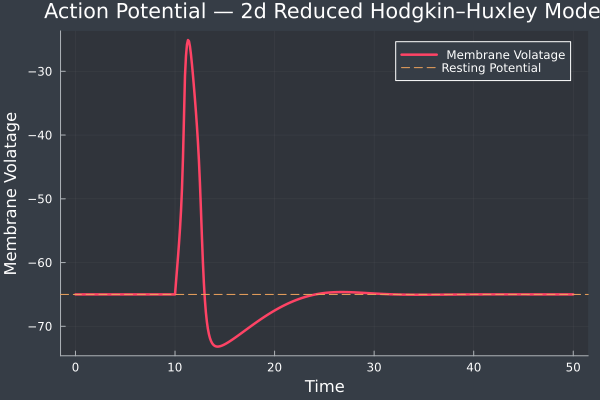

In [12]:
using Plots
theme(:dark)
plot(t,V, xlabel="Time" , ylabel="Membrane Volatage",linewidth = 2.5 ,title = "Action Potential — 2d Reduced Hodgkin–Huxley Model" ,label = " Membrane Volatage")
hline!([-65], linestyle=:dash ,    label = "Resting Potential")

In [13]:

# A gaussian noise is  add
# GAUSSIAN NOISE are unbiased , realistic and statistically justified noise that contians the many samll random affects added up to gather
# Noise in neuronal dynamics represents unresolved microscopic processes and measurement uncertainty 
#that collectively perturb the membrane voltage.

    using Statistics , Random

    function add_noise(t,V,strength)

        σ_V = std(V)
        
        σ_V_strength = strength * σ_V
    



        # Generating the gaussian noise
        noised_V  = randn(length(V)).*  σ_V_strength
        

        return V .+ noised_V 



        
    end

add_noise (generic function with 1 method)

In [14]:
    Random.seed!(1234)

    V_05  = add_noise(t,V,0.05)
    V_20  = add_noise(t,V,0.20)


    # @save "synthetic_data/noise_5_hh_2d_model.jld" t , V=V_05 , 


501-element Vector{Float64}:
 -66.60390025126893
 -66.74573967789948
 -64.23347963957627
 -63.44848877400499
 -66.72725542020991
 -65.89580470395407
 -63.583198089937454
 -62.16959568762712
 -64.31732763901657
 -65.9521170081922
   ⋮
 -64.60890847479236
 -64.37316508117385
 -65.26393963171607
 -64.77014961787614
 -62.7927010764557
 -64.44249189516172
 -64.52033934777755
 -65.75172788722267
 -63.96066910097193

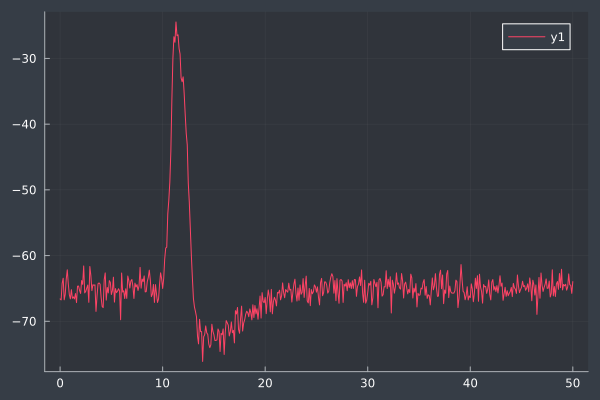

In [15]:
plot(t,V_20)

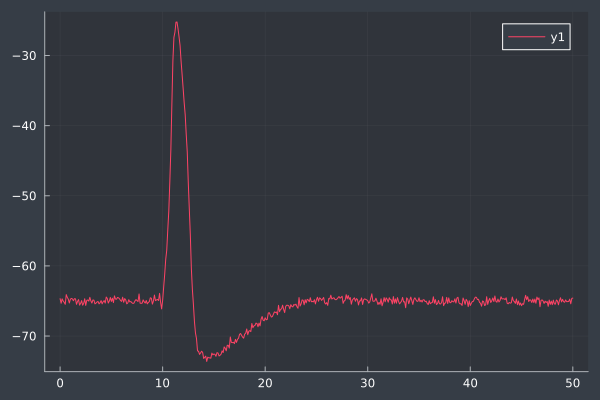

In [16]:
plot(t,V_05)

In [19]:
# Lets Save the data

@save "synthetic_data/noise_05_hh_2d_model.jld2" t=t  V =V_05 n=n2
@save "synthetic_data/noise_20_hh_2d_model.jld2" t=t  V = V_20 n=n2

In [18]:
data=@load"synthetic_data/noise_05_hh_2d_model.jld2"

3-element Vector{Symbol}:
 :t
 :V
 :n

# Loding the experimental data

In [8]:
using CSV, DataFrames
path1 = raw"C:\nirbhay\Downloads\Telegram Desktop\neuron_data_noise1.csv"
path2 = raw"C:\nirbhay\Downloads\Telegram Desktop\human_neuron_data.csv"
df2  = CSV.read(path1, DataFrame)
df = CSV.read(path2, DataFrame)

Row,Time_ms,Input_Current_pA,Membrane_Voltage_mV
,Float64,Float64,Float64
1,0.0,0.0,-72.3125
2,0.005,0.0,-72.3438
3,0.01,0.0,-72.3125
4,0.015,0.0,-72.375
5,0.02,0.0,-72.3438
6,0.025,0.0,-72.4063
7,0.03,0.0,-72.3438
8,0.035,0.0,-72.3438
9,0.04,0.0,-72.3438


In [11]:
println("human_neuron_data = $(size(df))")
println("maximum =  $(maximum(df.Input_Current_pA))")
println("minimum =  $(minimum(df.Input_Current_pA))")
println("std =  $(std(df.Input_Current_pA))")
println("mean =  $(mean(df.Input_Current_pA))")

println("-------------------")


println("mouse_neuron_data = $(size(df2))")
println("maximum =  $(maximum(df2.current_pa))")
println("minimum =  $(minimum(df2.current_pa))")
println("std =  $(std(df2.current_pa))")
println("mean =  $(mean(df2.current_pa))")


human_neuron_data = (8404001, 3)
maximum =  304.99999748023754
minimum =  -81.50000119222511
std =  46.648125661870495
mean =  53.557830935350054
-------------------
mouse_neuron_data = (5604001, 3)
maximum =  139.125
minimum =  0.0
std =  32.12164335958135
mean =  19.289867787705607


# Lets Plot and see the graphs

In [ ]:
# df ---> human neuron
# df2---> mouse neuron
plot(df2.time_ms,df2.voltage_mv)    

In [ ]:
plot(df2.time_ms , df2.current_pa)

In [ ]:
plot(df.Time_ms , df.Membrane_Voltage_mV)

In [ ]:
plot(df.Time_ms , df.Input_Current_pA	)

In [16]:
t_start_m = 10200.0
t_end_m   = 10700.0

downsample_m = 10

mask_m = (df2.time_ms .>= t_start_m) .& (df2.time_ms .<= t_end_m)
df_m_slice = df2[mask_m, :]

down_sampling = 10
df_m_final = df_m_slice[1:downsample_m:end, :]
t_mouse = df_m_final.time_ms .- df_m_final.time_ms[1]



10000-element Vector{Float64}:
   0.0
   0.049999999999272404
   0.09999999999854481
   0.1499999999996362
   0.1999999999989086
   0.249999999998181
   0.2999999999992724
   0.3499999999985448
   0.3999999999978172
   0.4499999999989086
   ⋮
 499.5499999999993
 499.59999999999854
 499.6499999999978
 499.6999999999989
 499.75
 499.7999999999993
 499.85000000000036
 499.89999999999964
 499.9499999999989

In [17]:
V_mouse = df_m_final.voltage_mv
I_mouse = df_m_final.current_pa


10000-element Vector{Float64}:
 51.5
 51.625
 51.875
 52.0
 52.249996
 52.499996
 52.624996
 52.875
 53.125
 53.375
  ⋮
 47.375
 47.25
 47.125
 47.0
 46.875
 46.75
 46.625
 46.5
 46.5

In [25]:
using Plots
theme(:dark)
plot(t_mouse,V_mouse)
plot(t_mouse,V_mouse)
@save "mouse_experimental_data.jld2" t = t_mouse , V = V_mouse